#**Project Title**:
##**Analyzing the Impact of AI Adoption & Job Automation on Employment Risk**

##**Problem Statement:**

This project aims to analyze the impact of Artificial Intelligence (AI) adoption and workplace automation on employment risk by examining how workforce characteristics, job requirements, and AI exposure influence layoff risk. Through Exploratory Data Analysis (EDA), the study will identify patterns and relationships between factors such as industry, job role, experience, creativity, human interaction, AI usage, and automation levels to understand which employee groups are most vulnerable or resilient in an increasingly AI-driven workplace.


##**Objective**:

The primary objective of this project is to analyze the relationship between:

1. AI adoption and workforce employment risk
2. Job automation and layoff vulnerability
3. Employee skills and adaptability
4. Industry-specific AI transformation
5. Workforce characteristics that influence employment stability

##**About the Dataset:**

This project utilizes the **AI Impact on Jobs and Layoff Risk Dataset** from **Kaggle**, a synthetic dataset containing 20,000 employee records across multiple industries. The dataset includes demographic information, professional background, job characteristics, AI adoption metrics, automation exposure indicators, and employee skill-related attributes. It is designed to simulate real-world workforce scenarios and enables the analysis of how AI integration, task automation, and workforce characteristics influence employment outcomes and layoff risk in an evolving AI-driven economy.


###**Data Understanding**

In [ ]:
# Import the Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the Dataset
df = pd.read_csv("/content/ai-impact-jobs-layoff-risk-dataset.csv")
df.head()

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


In [ ]:
# Shape of the dataset
df.shape

(20000, 16)

**Observation:** There are **20,000 rows & 16 columns** present in the dataset.

In [ ]:
# Info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         20000 non-null  int64 
 1   Education_Level             20000 non-null  object
 2   Years_of_Experience         20000 non-null  int64 
 3   Industry                    20000 non-null  object
 4   Job_Role                    20000 non-null  object
 5   Company_Size                20000 non-null  object
 6   Job_Level                   20000 non-null  object
 7   Routine_Task_Percentage     20000 non-null  int64 
 8   Creativity_Requirement      20000 non-null  int64 
 9   Human_Interaction_Level     20000 non-null  int64 
 10  AI_Adoption_Level           20000 non-null  object
 11  Number_of_AI_Tools_Used     20000 non-null  int64 
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64 
 13  Tasks_Automated_Percentage  20000 non-null  in

In [ ]:
# Classifying columns based on their datatypes
numerical_cols = df.select_dtypes(include="int64").columns.to_list()
categorical_cols = df.select_dtypes(include="object").columns.to_list()

print(f"Numerical Columns: {numerical_cols}\n")
print(f"Categorical Columns: {categorical_cols}")

Numerical Columns: ['Age', 'Years_of_Experience', 'Routine_Task_Percentage', 'Creativity_Requirement', 'Human_Interaction_Level', 'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage', 'AI_Training_Hours']

Categorical Columns: ['Education_Level', 'Industry', 'Job_Role', 'Company_Size', 'Job_Level', 'AI_Adoption_Level', 'Layoff_Risk']


###**Data Cleaning**

In [ ]:
# Check for missing values
df.isnull().sum()

,0
Age,0
Education_Level,0
Years_of_Experience,0
Industry,0
Job_Role,0
Company_Size,0
Job_Level,0
Routine_Task_Percentage,0
Creativity_Requirement,0
Human_Interaction_Level,0


**Observation:** There are no missing values in the dataset.

In [ ]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

**Observation:** There are no duplicate values in the dataset.

## **Target Variable Univariate Analysis**

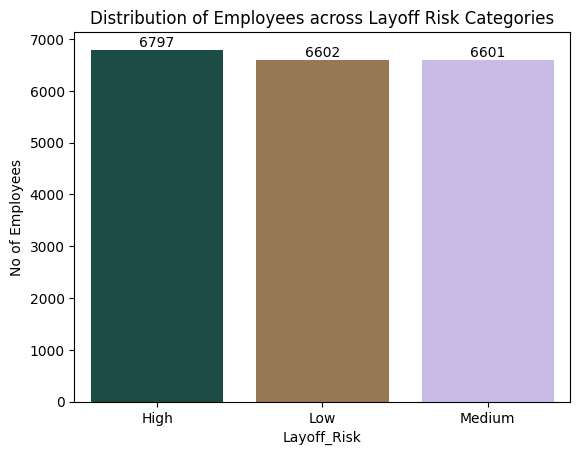

In [ ]:
# Target Variable Analysis
layoffs_count = df["Layoff_Risk"].value_counts()
a = sns.barplot(x=layoffs_count.index,y=layoffs_count.values,
            palette="cubehelix",hue=layoffs_count.index,legend=False)
for container in a.containers:
  a.bar_label(container)
plt.title("Distribution of Employees across Layoff Risk Categories")
plt.ylabel("No of Employees")
plt.show()

**Observation:**

This indicates that the dataset is **well-balanced**  with respect to the target variable across the three layoff risk categories
(High, Low, and Medium) with each category containing approximately one-third of the total records.


## **Demographic Analysis**

**1. Age Distribution**

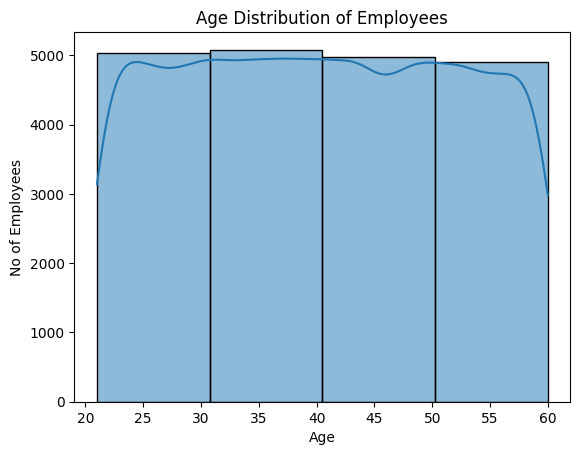

In [ ]:
sns.histplot(df,x="Age",bins=4,kde=True)
plt.title("Age Distribution of Employees")
plt.ylabel("No of Employees")
plt.show()

**Observation:**

The age distribution is fairly uniform across the range of 21 to 60 years. No specific age group dominates the workforce.

In [ ]:
df.groupby("Layoff_Risk")["Age"].mean().sort_values()

,Age
Layoff_Risk,
High,39.863469
Medium,40.334495
Low,40.901242


**Observation:**
Since the average ages are very similar, this shows that age has very little influence on layoff risk.

**2. Education Level Distribution**

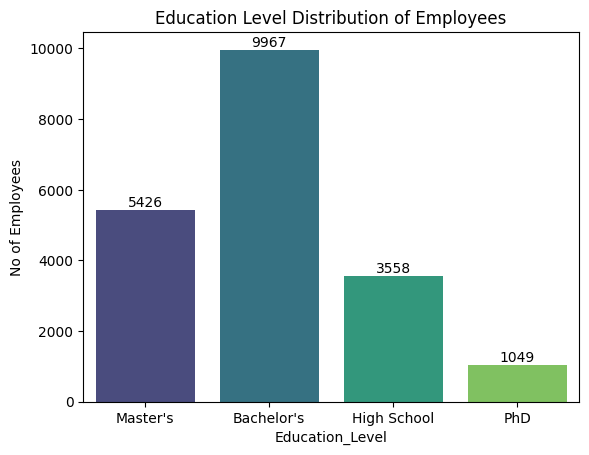

In [ ]:
a = sns.countplot(df,x="Education_Level",palette="viridis",
                  hue="Education_Level",legend=False)
for container in a.containers:
  a.bar_label(container)
plt.title("Education Level Distribution of Employees")
plt.ylabel("No of Employees")
plt.show()

**Observation:**

Bachelor's degree holders constitute the largest proportion of employees (9,967), accounting for nearly half of the workforce. Master's degree holders (5,426) form the second-largest group, followed by High School graduates (3,558), while PhD holders (1,049) represent the smallest segment.

In [ ]:
pd.crosstab(df["Education_Level"],df["Layoff_Risk"],normalize="index") * 100

Layoff_Risk,High,Low,Medium
Education_Level,,,
Bachelor's,35.055684,31.243102,33.701214
High School,45.559303,21.950534,32.490163
Master's,27.110210,40.287505,32.602285
PhD,20.114395,49.666349,30.219256


**Observation:**

Employees with a **High School qualification** are more frequently represented in the High layoff risk category, whereas **PhD holders** are more commonly found in the Low layoff risk category.

This suggests a positive association between higher educational attainment and lower layoff risk.

**3. Work Experience Distribution**

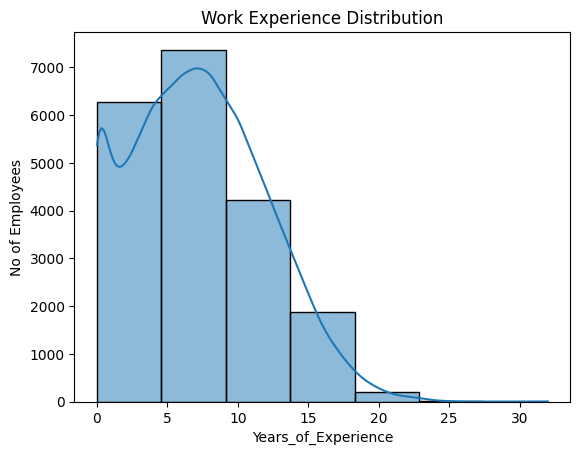

In [ ]:
sns.histplot(df,x="Years_of_Experience",bins=7,kde=True)
plt.title("Work Experience Distribution")
plt.ylabel("No of Employees")
plt.show()

**Observation:**

The distribution of work experience is positively skewed, with most employees having between 0 and 12 years of experience. The number of employees decreases as experience increases, resulting in relatively fewer highly experienced professionals.

## **Industry Analysis**

**1. Which industries have the most employees?**

In [ ]:
df["Industry"].value_counts()

,count
Industry,
Telecom,2582
Healthcare,2561
Finance,2513
Logistics,2488
IT,2483
Retail,2467
Manufacturing,2457
Education,2449


**Observation: Telecom Industry** has the most no of employees **(2582)** in the dataset.

**2. Which job role is most represented?**

In [ ]:
df["Job_Role"].value_counts().idxmax()

'Nurse'

**Observation: "Nurse"** job role is most observed in the dataset.

**3. Employees across different company sizes**

In [ ]:
df["Company_Size"].value_counts()

,count
Company_Size,
Medium,8964
Small,6066
Large,4970


**Observation:**

 Most of the employees work in the **medium size** companies (8964). Small size companies workers form the second-largest group (6066), followed by the large size companies (4970).

**4. Employees across different job levels**

In [ ]:
df["Job_Level"].value_counts()

,count
Job_Level,
Entry,9016
Mid,7940
Senior,3044


**Observation:** Most of the employees are **entry level** employees (9016), accounting for nearly half of the workforce.

**5. Industry-wise AI adoption**

In [ ]:
pd.crosstab(df["Industry"],df["AI_Adoption_Level"]).sort_values("High",
ascending=False)

AI_Adoption_Level,High,Low,Medium
Industry,,,
IT,199,1291,993
Manufacturing,184,1259,1014
Healthcare,179,1358,1024
Finance,176,1302,1035
Telecom,176,1406,1000
Education,175,1250,1024
Logistics,164,1323,1001
Retail,162,1350,955


**Observation: IT Industry** has most AI adoption level with 199 employees.

**6. Industry-wise average automation exposure**

In [ ]:
df.groupby("Industry")["Tasks_Automated_Percentage"].mean().sort_values(ascending=False)

,Tasks_Automated_Percentage
Industry,
Manufacturing,37.969068
Education,37.700694
Finance,37.530044
IT,37.427708
Logistics,37.278135
Healthcare,36.969153
Telecom,36.807901
Retail,36.177544


**Observation:**

**Manufacturing Industry** has most automation exposure with an average of 38% tasks automated for each employee in that sector.

**7. Industry-wise layoff risk**

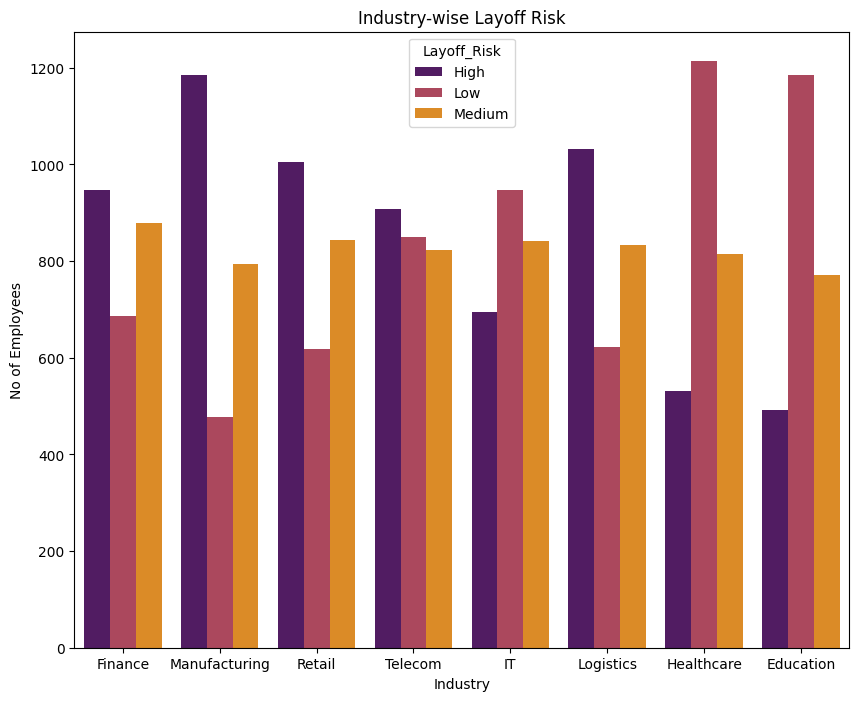

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(df,x="Industry",hue="Layoff_Risk",palette="inferno")
plt.title("Industry-wise Layoff Risk")
plt.ylabel("No of Employees")
plt.show()

**Observation:**

1. **Manufacturing, Retail, Logistics, and Finance** have the highest number of employees in the High Layoff Risk category, suggesting that these industries may be more vulnerable to automation and AI-driven workforce disruption.

2. In contrast, **Healthcare and Education** show the highest number of employees in the Low Layoff Risk category and the lowest number in the High-risk category, indicating greater employment stability.


## **Job Role Analysis**

**1. AI adoption by job roles**

In [ ]:
pd.crosstab(df["Job_Role"],df["AI_Adoption_Level"]).sort_values("High",ascending=False)

AI_Adoption_Level,High,Low,Medium
Job_Role,,,
Data Analyst,76,442,331
Production Supervisor,72,410,324
ML Engineer,68,414,323
Inventory Analyst,68,454,335
Operator,68,428,362
Medical Assistant,67,465,357
Accountant,67,401,353
Network Engineer,65,471,326
Financial Analyst,63,473,343


**Observation:**

**Data Analyst & Production Supervisor** roles have highest AI adoption level. In contrast, **Sales Associate & Quality Engineer** have lowest AI adoption level.

**2. Average Automation Exposure across job roles**

In [ ]:
df.groupby("Job_Role")["Tasks_Automated_Percentage"].mean().sort_values(ascending=False)

,Tasks_Automated_Percentage
Job_Role,
Operator,38.623543
Accountant,38.468940
Academic Coordinator,38.328449
Production Supervisor,37.980149
Dispatcher,37.934010
Research Assistant,37.676039
Software Engineer,37.652593
Health Analyst,37.645078
Auditor,37.479705


**Observation:**

**Operator, Accountant & Academic Coordinator** roles have highest average automation exposure. In contrast, **Nurse, Operations Analyst & Sales Associate** have lowest average automation exposure.

**3. Layoff Risk across job roles**

In [ ]:
job_risk = pd.crosstab(df["Job_Role"],df["Layoff_Risk"],normalize="index") * 100

In [ ]:
job_risk.sort_values(by="High",ascending=False)

Layoff_Risk,High,Low,Medium
Job_Role,,,
Operator,50.233100,20.862471,28.904429
Production Supervisor,48.263027,18.114144,33.622829
Quality Engineer,46.027743,19.293821,34.678436
Inventory Analyst,44.574096,21.703617,33.722287
Dispatcher,42.131980,23.477157,34.390863
Warehouse Manager,41.281139,25.860024,32.858837
Supply Chain Analyst,41.190198,25.554259,33.255543
Sales Associate,40.644362,22.800496,36.555143
Accountant,39.585871,26.918392,33.495737


**Observation:**

1. **Operator, Production Supervisor & Inventory Analyst** roles have most of the employees in high risk category, suggesting that these roles are more vulnerable to automation & AI-driven workforce disruption.

2. In contrast, **Health Analyst, Nurse & Teacher** roles have most of the employees in low risk category and less no of employees in high risk category, suggesting that these job roles are more stable and less afftected by automation & AI.

##**AI Adoption Analysis**

**1. Distribution of AI Adoption Level**

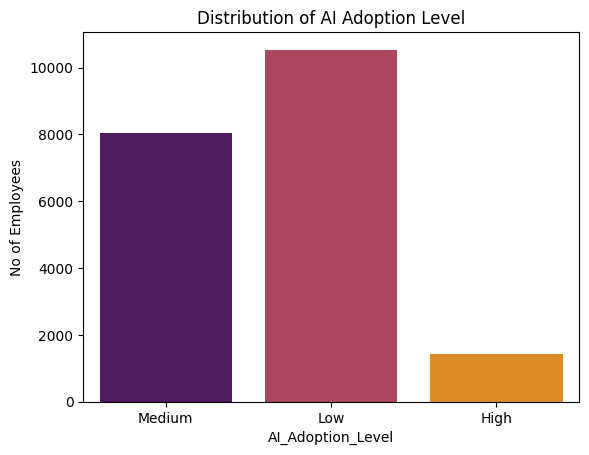

In [ ]:
sns.countplot(data=df,x="AI_Adoption_Level",palette="inferno",hue="AI_Adoption_Level",legend=False)
plt.title("Distribution of AI Adoption Level")
plt.ylabel("No of Employees")
plt.show()

**Observation:**

More than **10,000 employees** have low AI adoption level, accounting for nearly half of the workforce.

8000 employees have medium AI adoption level, then followed by very few - less than 2000 employees have high AI adoption level.

**2. AI Engagement Score - (No_of_AI_Tools_Used) x  (AI_Usage_Hrs_Per_Week)**

In [ ]:
df["AI_Engagement_Score"] = df["Number_of_AI_Tools_Used"] * df["AI_Usage_Hours_Per_Week"]

In [ ]:
df.groupby("AI_Adoption_Level")["AI_Engagement_Score"].mean().sort_values()

,AI_Engagement_Score
AI_Adoption_Level,
Low,2.507354
Medium,33.421949
High,169.284806


**Observation:**

Employees in organizations with higher AI adoption levels tend to have higher AI engagement scores, indicating a positive relationship between AI adoption and employee AI usage.

**3. Does AI adoption increase or decrease employment stability?**

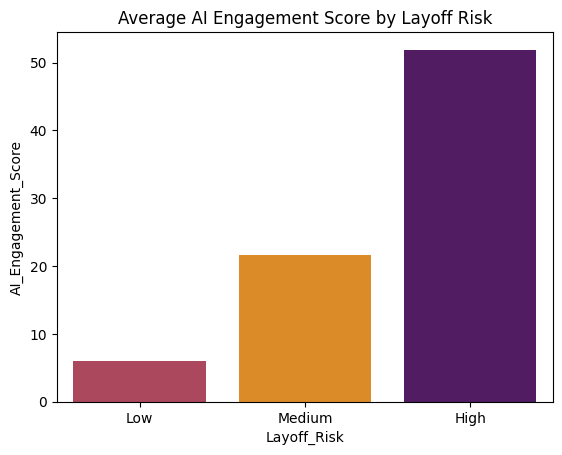

In [ ]:
sns.barplot(data=df,x="Layoff_Risk",y="AI_Engagement_Score",palette="inferno", hue="Layoff_Risk",order=["Low","Medium","High"],estimator="mean",legend=False,errorbar=None)
plt.title("Average AI Engagement Score by Layoff Risk")
plt.show()

**Observation:**

It is observed that higher the AI adoption level, higher the layoff risk which leads to decline in the employment stability.

On the other hand, low AI adoption level has lowest layoff risk which leads to more employment stability.

##**Automation Analysis**

**1. Automation Exposure Score - (Routine_Task% + Tasks_Automated%) / 2**

In [ ]:
df["Automation_Exposure_Score"] = (df["Routine_Task_Percentage"] + df["Tasks_Automated_Percentage"]) / 2

**2. Which industry has the highest automation exposure?**

In [ ]:
df.groupby("Industry")["Automation_Exposure_Score"].mean().sort_values(ascending=False)

,Automation_Exposure_Score
Industry,
Manufacturing,45.363655
Education,45.164761
Finance,44.995026
IT,44.888844
Logistics,44.532958
Healthcare,44.135884
Telecom,44.044539
Retail,43.369680


**Observation:**

**Manufacting** industry employees have the highest mean automation exposure.

**3. Which job role has the highest automation exposure?**

In [ ]:
df.groupby("Job_Role")["Automation_Exposure_Score"].mean().idxmax()

'Accountant'

**Observation:**
**Accountant** role has the highest mean automation exposure.

**4. Does automation exposure directly correlate with layoff risk?**

In [ ]:
df.groupby("Layoff_Risk")["Automation_Exposure_Score"].mean().sort_values()

,Automation_Exposure_Score
Layoff_Risk,
Low,23.995683
Medium,43.490229
High,65.565102


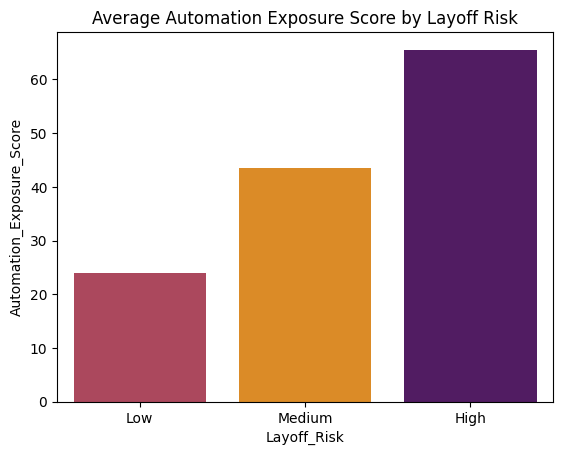

In [ ]:
sns.barplot(data=df,x="Layoff_Risk",y="Automation_Exposure_Score",palette="inferno", hue="Layoff_Risk",order=["Low","Medium","High"],estimator="mean",legend=False,errorbar=None)
plt.title("Average Automation Exposure Score by Layoff Risk")
plt.show()

**Observation:**

Employees with higher automation exposure scores tend to have higher layoff risk, indicating a positive relationship between automation exposure and employment vulnerability.

##**Skill & Adaptability Analysis**

**1. Workforce Adaptability Score - (Creativity_Requirement + Human_Interaction_Level + AI_Training_Hours) / 3**

In [ ]:
df["Work_Adaptability_Score"] = (df["Creativity_Requirement"] + df["Human_Interaction_Level"] + df["AI_Training_Hours"]) / 3

**2. Does adaptability score protect employees from high layoff risk?**

In [ ]:
df.groupby("Layoff_Risk")["Work_Adaptability_Score"].mean().sort_values(ascending=False)

,Work_Adaptability_Score
Layoff_Risk,
Low,47.508583
Medium,39.817957
High,33.337845


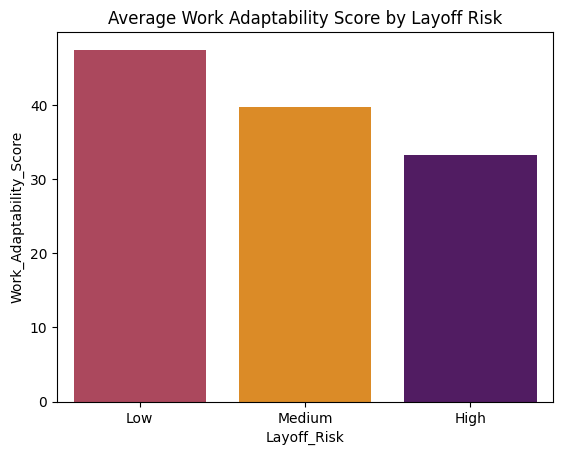

In [ ]:
sns.barplot(data=df,x="Layoff_Risk",y="Work_Adaptability_Score",estimator="mean",palette="inferno",order=["Low","Medium","High"],hue="Layoff_Risk",legend=False,errorbar=None)
plt.title("Average Work Adaptability Score by Layoff Risk")
plt.show()

**Observation:**

Average adaptability score is higher for low layoff risk group and low for high layoff risk group, suggesting that higher adaptability is associated with greater employment stability.

##**Company Analysis**

In [ ]:
df.groupby("Company_Size")["AI_Engagement_Score"].mean()

,AI_Engagement_Score
Company_Size,
Large,25.672435
Medium,26.878291
Small,27.422849


In [ ]:
df.groupby("Company_Size")["Automation_Exposure_Score"].mean()

,Automation_Exposure_Score
Company_Size,
Large,44.274547
Medium,44.797133
Small,44.434306


In [ ]:
df.groupby("Company_Size")["Work_Adaptability_Score"].mean()

,Work_Adaptability_Score
Company_Size,
Large,40.143930
Medium,40.206530
Small,40.085834


In [ ]:
pd.crosstab(df["Company_Size"],df["Layoff_Risk"],normalize="index") * 100

Layoff_Risk,High,Low,Medium
Company_Size,,,
Large,33.158954,34.044266,32.796781
Medium,34.917448,32.373940,32.708612
Small,33.283877,33.102539,33.613584


**Observation:** Company size doesn't have any impact on layoff risk and it doesn't affect the employement stability.



##**Job Level Analysis**

In [ ]:
df.groupby("Job_Level")["AI_Engagement_Score"].mean()

,AI_Engagement_Score
Job_Level,
Entry,27.094720
Mid,26.750504
Senior,25.686925


In [ ]:
df.groupby("Job_Level")["Automation_Exposure_Score"].mean()

,Automation_Exposure_Score
Job_Level,
Entry,44.657054
Mid,44.458186
Senior,44.519875


In [ ]:
df.groupby("Job_Level")["Work_Adaptability_Score"].mean()

,Work_Adaptability_Score
Job_Level,
Entry,40.152137
Mid,40.144458
Senior,40.186816


In [ ]:
pd.crosstab(df["Job_Level"],df["Layoff_Risk"],normalize="index") * 100

Layoff_Risk,High,Low,Medium
Job_Level,,,
Entry,44.509760,22.759539,32.730701
Mid,30.667506,35.176322,34.156171
Senior,11.465177,57.720105,30.814717


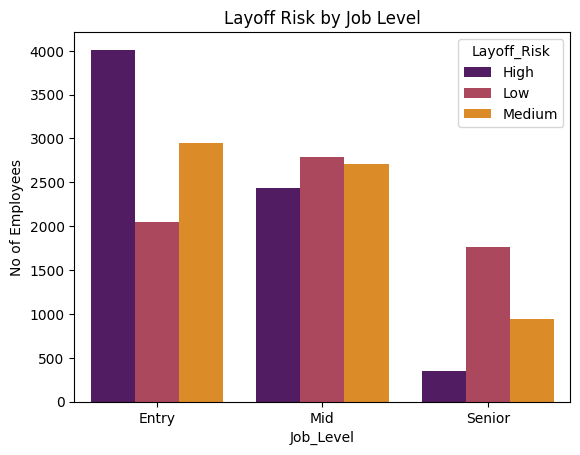

In [ ]:
sns.countplot(data=df,x="Job_Level",hue="Layoff_Risk",palette="inferno",order=["Entry","Mid","Senior"])
plt.title("Layoff Risk by Job Level")
plt.ylabel("No of Employees")
plt.show()

**Observation:**

This indicates that, most of the **Entry Level employees (4000)** are in the high  layoff risk category and are more vulnerable to Automation and AI-driven workforce.

On the other hand, very few **Senior Level employees (less than 500)** are in the high layoff risk category, suggesting that more work experience is strongly associated with greater employment stability.

##**Layoff Risk Analysis using Derived Features**

In [ ]:
df.groupby("Layoff_Risk")[
    [
        "AI_Engagement_Score",
        "Automation_Exposure_Score",
        "Work_Adaptability_Score"
    ]
].mean()

,AI_Engagement_Score,Automation_Exposure_Score,Work_Adaptability_Score
Layoff_Risk,,,
High,51.921436,65.565102,33.337845
Low,5.981218,23.995683,47.508583
Medium,21.584305,43.490229,39.817957


**Observation:**

1. High AI enagagement is strongly associated with high layoff risk.

2. More automation exposure is strongly associated with high layoff risk.

3. Higher work adaptability is strongly associated with low layoff risk.

##**Research Questions**

###**1. Which industries exhibit the highest levels of AI adoption and automation?**

In [ ]:
df["AI_Automation_Index"] = (df["AI_Engagement_Score"] + df["Automation_Exposure_Score"]) / 2

In [ ]:
df.groupby("Industry")["AI_Automation_Index"].mean().sort_values(ascending=False)

,AI_Automation_Index
Industry,
IT,36.652235
Manufacturing,36.605922
Education,36.401082
Finance,35.797354
Healthcare,35.389106
Logistics,35.336415
Telecom,34.984508
Retail,34.081273


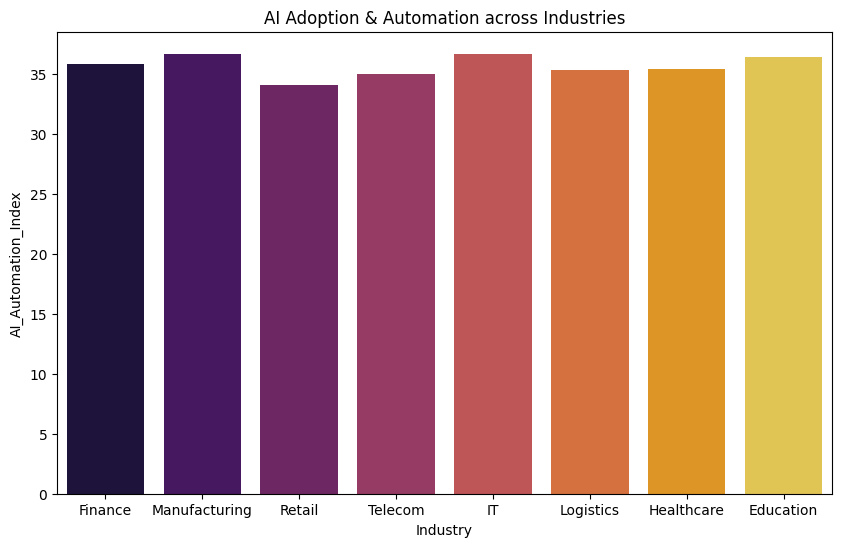

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x="Industry",y="AI_Automation_Index",estimator="mean",palette="inferno",hue="Industry",legend=False,errorbar=None)
plt.title("AI Adoption & Automation across Industries")
plt.show()

**Observation:**

**IT, Manufacturing & Education** industries have highest levels of AI adoption & Automation.

###**2. Which industries have employees facing the highest layoff risk?**

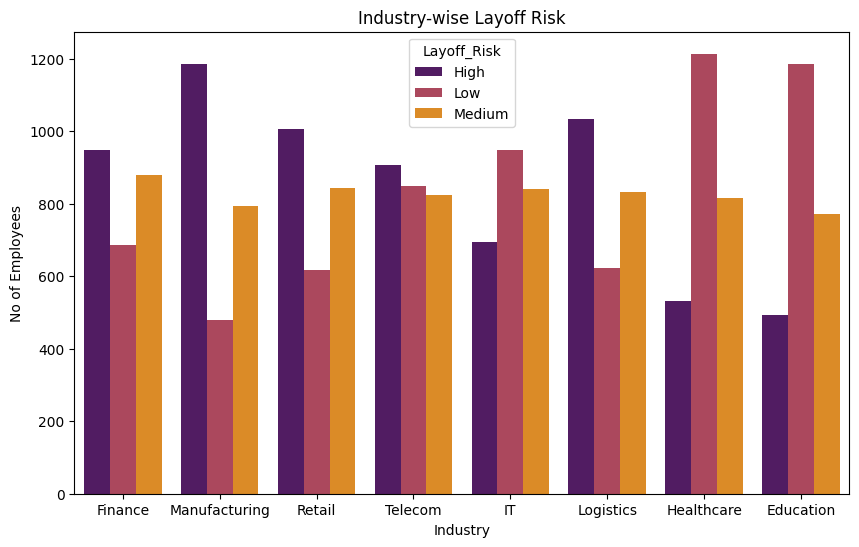

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(df,x="Industry",hue="Layoff_Risk",palette="inferno")
plt.title("Industry-wise Layoff Risk")
plt.ylabel("No of Employees")
plt.show()

**Observation:**

**Manufacturing, Retail, Logistics, and Finance** have most number of employees in the High Layoff Risk category, suggesting that these industries may be more vulnerable to automation and AI-driven workforce disruption.

###**3. How does AI adoption vary across different job roles?**

In [ ]:
df.groupby("Job_Role")["AI_Engagement_Score"].mean().sort_values(ascending=False)

,AI_Engagement_Score
Job_Role,
Production Supervisor,30.480149
Data Analyst,29.873969
ML Engineer,29.144099
Accountant,29.045067
Operator,28.986014
Teacher,28.387931
Academic Coordinator,27.598291
Medical Assistant,27.385827
Inventory Analyst,26.996499


**Observation:**

**Production Supervisor, Data Analyst, ML Engineer & Accountant** roles have high level of AI adoption, whereas **Auditor, Quality Engineer & Sales Associate** roles have low level of AI adoption.

###**4. Does a higher percentage of routine tasks increase layoff risk?**

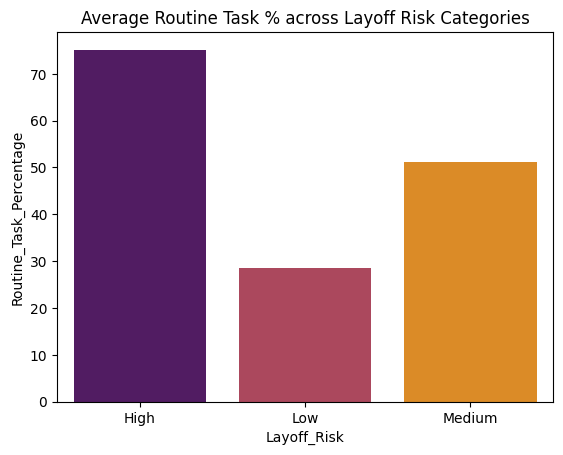

In [ ]:
sns.barplot(data=df,x="Layoff_Risk",y="Routine_Task_Percentage",estimator="mean",palette="inferno",hue="Layoff_Risk",legend=False,errorbar=None)
plt.title("Average Routine Task % across Layoff Risk Categories")
plt.show()

**Observation:**

Yes, high percentage of routine tasks is strongly associated with high layoff risk as most of the routine tasks are automated using AI.

###**5. Does creativity requirement reduce employee vulnerability to automation?**

In [ ]:
df["Creativity_Requirement"].corr(df["Automation_Exposure_Score"])

np.float64(-0.9076185448928294)

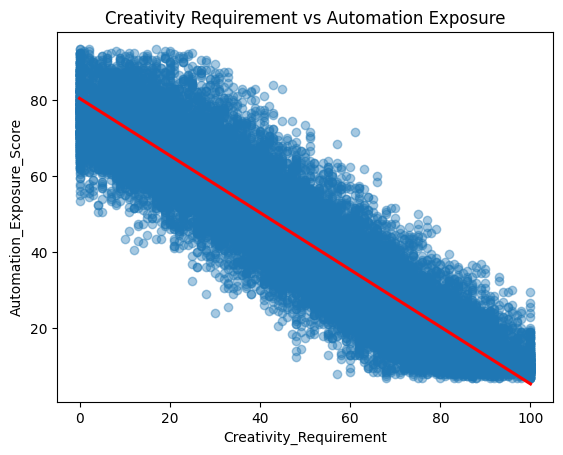

In [ ]:
sns.regplot(data=df,x="Creativity_Requirement",y="Automation_Exposure_Score",
    scatter_kws={"alpha": 0.4},line_kws={"color": "red"})
plt.title("Creativity Requirement vs Automation Exposure")
plt.show()

**Observation:**

The analysis suggests that higher creativity requirements are strongly associated with lower automation exposure. Therefore, employees performing more creative tasks appear to be less vulnerable to automation.

###**6. How does human interaction level affect employment stability?**

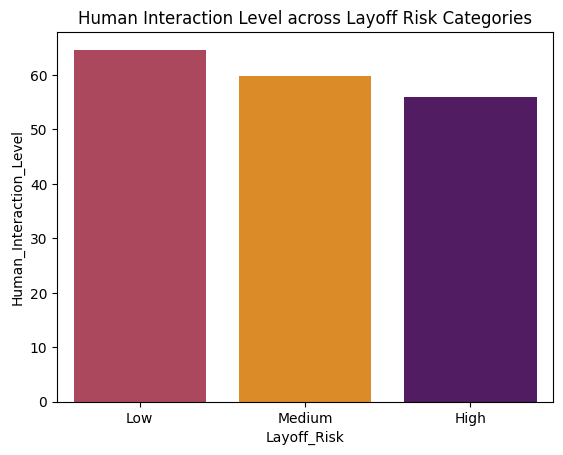

In [ ]:
sns.barplot(data=df,x="Layoff_Risk",y="Human_Interaction_Level",estimator="mean",palette="inferno",order=["Low","Medium","High"],hue="Layoff_Risk",legend=False,errorbar=None)
plt.title("Human Interaction Level across Layoff Risk Categories")
plt.show()

**Observation:**

High human interaction level is strongly associated with low layoff risk. Employees those who interact more in the work are less vulnerable to AI & Automation.

###**7. What is the relationship between AI training hours and layoff risk?**

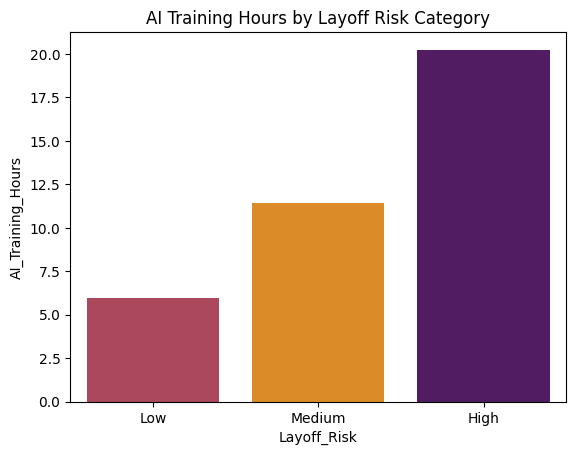

In [ ]:
sns.barplot(data=df,x="Layoff_Risk",y="AI_Training_Hours",estimator="mean",palette="inferno",order=["Low","Medium","High"],hue="Layoff_Risk",legend=False,errorbar=None)
plt.title("AI Training Hours by Layoff Risk Category")
plt.show()

**Observation:**

Employees in the High Layoff risk category receive the highest average AI training hours, followed by those in the Medium and Low risk categories. This indicates a positive association between AI training hours and layoff risk in this dataset.

###**8. How does employee experience influence automation exposure?**

In [ ]:
df["Years_of_Experience"].corr(df["Automation_Exposure_Score"])

np.float64(-0.004034073030952788)

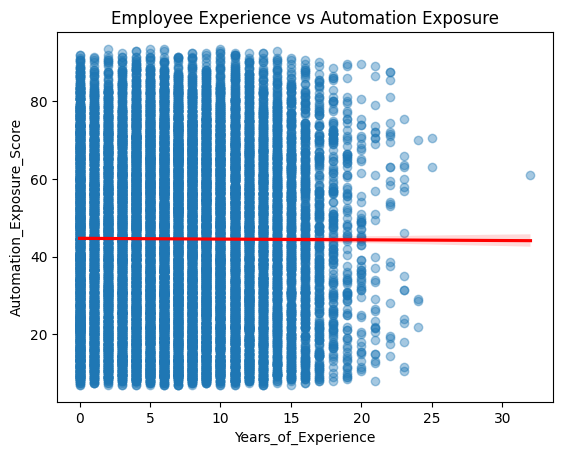

In [ ]:
sns.regplot(data=df,x="Years_of_Experience",y="Automation_Exposure_Score",
    scatter_kws={"alpha": 0.4},line_kws={"color": "red"})
plt.title("Employee Experience vs Automation Exposure")
plt.show()

**Observation:**

The scatter plot and regression line indicate that employee experience has **minimal influence** on automation exposure. Employees across all experience levels exhibit a wide range of automation exposure scores, suggesting that work experience alone is not a strong determinant of an employee's vulnerability to automation.

###**9. Do larger companies adopt AI more aggressively than smaller organizations?**

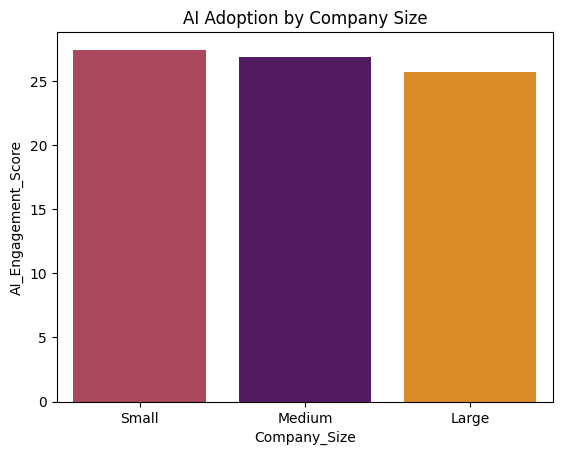

In [ ]:
sns.barplot(data=df,x="Company_Size",y="AI_Engagement_Score",estimator="mean",palette="inferno",order=["Small","Medium","Large"],hue="Company_Size",legend=False,errorbar=None)
plt.title("AI Adoption by Company Size")
plt.show()

**Observation:**

No, it is observed that small companies have adopted the AI most. Medium comapnies are next to small companies with mid level AI adoption, followed by large companies with least AI adoption.

###**10. How do AI usage hours and the number of AI tools used impact employment outcomes?**

In [ ]:
cols=["AI_Usage_Hours_Per_Week","Number_of_AI_Tools_Used"]
df.groupby("Layoff_Risk")[cols].mean()

,AI_Usage_Hours_Per_Week,Number_of_AI_Tools_Used
Layoff_Risk,,
High,10.767692,3.813006
Low,3.272796,1.254014
Medium,6.163309,2.274049


**Observation:**

It is observed that employees with both high AI usage hours & more AI tools usage are in high layoff risk category.

This suggests that less AI usage hours & less AI tools usage are strongly associated with greater employment stability.

###**11. Which employee groups are most resilient to AI-driven automation?**

**Observation:**

Following are the employee groups that are more resilient to AI-driven automation:

1. Employees with higher educational qualifications **(Master's & PhD)**
2. **Senior level** employees with more years of experience.
3. Employees who work in **Healthcare & Education** industries.
4. **Nurse & Teacher** job roles.
5. Employees with **high creativity requirements**, **greater human interaction levels**, **lower automation exposure**, and **higher workforce adaptability scores**.

These groups consistently exhibit a higher proportion of employees in the **Low layoff risk category**, indicating greater resilience to AI-driven automation.



###**12. What workforce characteristics are associated with High Layoff Risk?**

**Observation:**

Following are workforce characteristics that are associated with High Layoff Risk:

1. **Higher AI Engagement Scores**
2. **Higher Automation Exposure Scores**
3. **Higher Routine Task Percentage**
4. **Lower Work Adaptability Scores**
5. **Lower Human Interaction Levels**
6. **Lower Creativity Requirements**
7. A greater proportion of employees with **High School qualifications**.
8. More **Entry Level** roles.

##**Conclusion:**

The Exploratory Data Analysis reveals that **AI-driven automation has a significant association with employee layoff risk**. Employees performing highly routine and automatable tasks are more likely to face higher layoff risk, whereas those with higher creativity requirements, greater human interaction, stronger adaptability, and advanced educational qualifications tend to be more resilient. Additionally, AI adoption and automation levels vary across industries, highlighting that the impact of AI is not uniform across the workforce. These findings emphasize the importance of continuous upskilling, AI training, and developing human-centric skills to improve workforce resilience and help organizations effectively adapt to an increasingly AI-driven workplace.
